# Student Performance Predictor

## Machine Learning Internship Project

### Project Objective

The objective of this project is to build a machine learning model
that predicts a student's final marks based on study hours,
attendance, previous score, and assignment score.

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Joblib
- Jupyter Notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("student_performance.csv")

df.head()

df.duplicated().sum()

np.int64(5)

In [2]:
df = df.drop_duplicates()
df.duplicated().sum()
df.isnull().sum()
df["Study_Hours"] = df["Study_Hours"].fillna(df["Study_Hours"].median())

df["Attendance"] = df["Attendance"].fillna(df["Attendance"].median())

df["Previous_Score"] = df["Previous_Score"].fillna(df["Previous_Score"].median())

df["Assignments_Score"] = df["Assignments_Score"].fillna(df["Assignments_Score"].median())
df.isnull().sum()
df.shape

(1000, 5)

In [3]:
df.describe()

,Study_Hours,Attendance,Previous_Score,Assignments_Score,Final_Marks
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,5.415200,77.836400,67.617700,69.42100,63.550700
std,2.625453,13.089122,15.943633,17.16507,9.991371
min,1.000000,55.100000,40.000000,40.00000,36.000000
25%,3.100000,65.975000,54.550000,54.50000,56.900000
50%,5.500000,78.400000,67.500000,69.10000,63.300000
75%,7.700000,89.125000,81.700000,84.20000,70.825000
max,10.000000,100.000000,94.900000,100.00000,91.200000


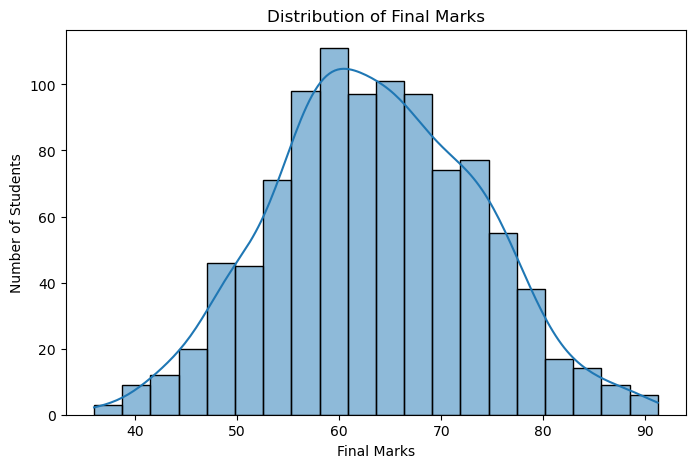

In [4]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Final_Marks"], bins=20, kde=True)

plt.title("Distribution of Final Marks")
plt.xlabel("Final Marks")
plt.ylabel("Number of Students")
plt.show()

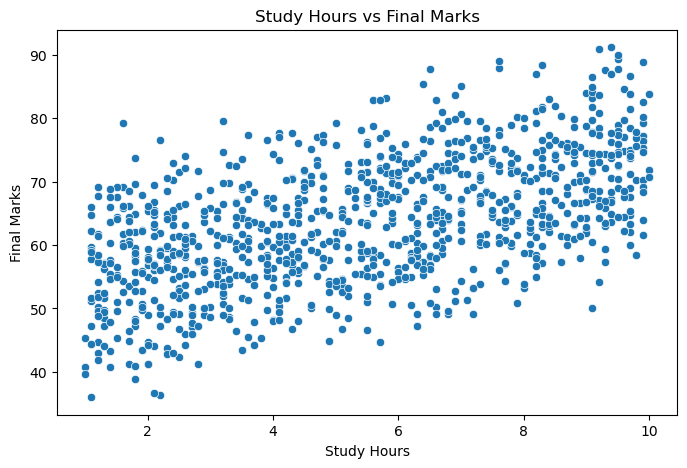

In [5]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x="Study_Hours",
    y="Final_Marks",
    data=df
)

plt.title("Study Hours vs Final Marks")
plt.xlabel("Study Hours")
plt.ylabel("Final Marks")
plt.show()

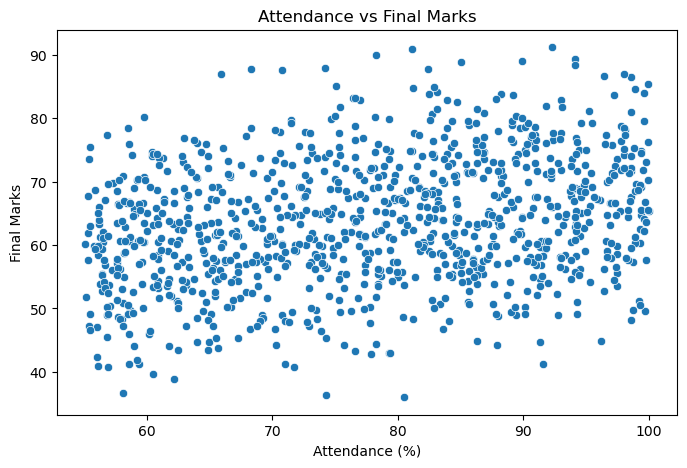

In [6]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x="Attendance",
    y="Final_Marks",
    data=df
)

plt.title("Attendance vs Final Marks")
plt.xlabel("Attendance (%)")
plt.ylabel("Final Marks")
plt.show()

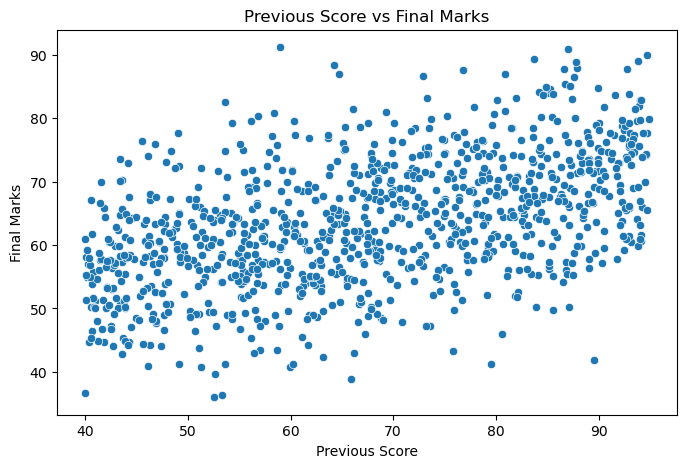

In [7]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x="Previous_Score",
    y="Final_Marks",
    data=df
)

plt.title("Previous Score vs Final Marks")
plt.xlabel("Previous Score")
plt.ylabel("Final Marks")
plt.show()

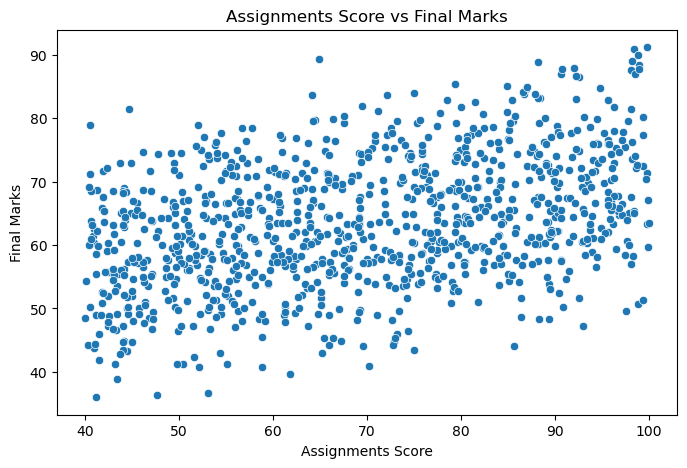

In [8]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x="Assignments_Score",
    y="Final_Marks",
    data=df
)

plt.title("Assignments Score vs Final Marks")
plt.xlabel("Assignments Score")
plt.ylabel("Final Marks")
plt.show()

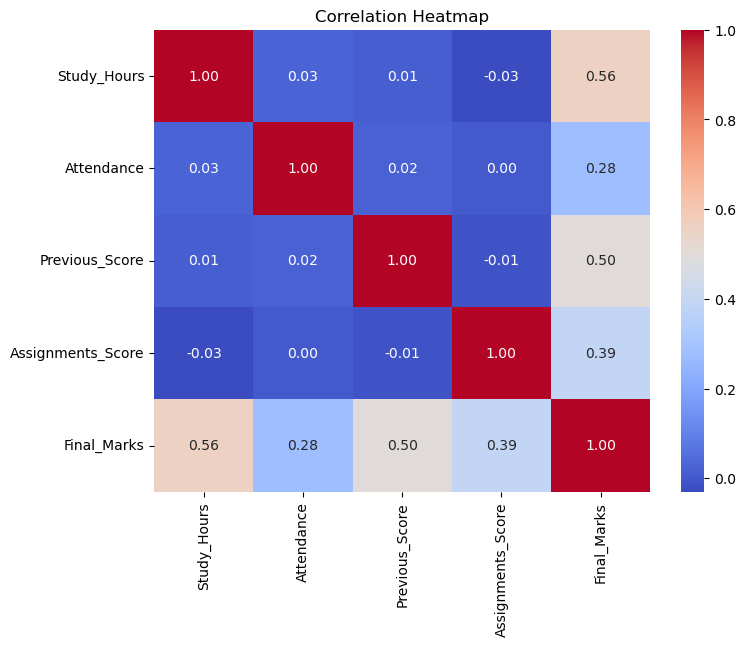

In [9]:
correlation = df.corr(numeric_only=True)

correlation
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

## EDA Summary
#The exploratory data analysis was performed to understand the relationship
#between student-related factors and final marks.

#The analysis examined study hours, attendance, previous scores, and
#assignment scores.

#Scatter plots were used to analyze relationships between the independent
#variables and final marks. The correlation heatmap was used to understand
#the strength and direction of relationships between numerical variables.

#These findings will help in selecting the features used for the machine
#learning model.

In [10]:
X = df[[
    "Study_Hours",
    "Attendance",
    "Previous_Score",
    "Assignments_Score"
]]

y = df["Final_Marks"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (800, 4)
Testing features: (200, 4)
Training target: (800,)
Testing target: (200,)


In [11]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()

model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)


comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_lr
})

comparison.head(10)

,Actual,Predicted
0,58.0,58.406463
1,76.5,71.708059
2,71.6,69.406843
3,59.7,61.529114
4,62.2,58.106727
5,74.1,67.996729
6,48.5,46.649453
7,76.0,75.815028
8,59.8,56.636959
9,58.4,63.568888


In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("-------------------------")
print("MAE:", mae)
print("MSE:", mse)
print("R² Score:", r2)

Linear Regression Results
-------------------------
MAE: 3.61411492610888
MSE: 20.60963850807069
R² Score: 0.7888826051678588


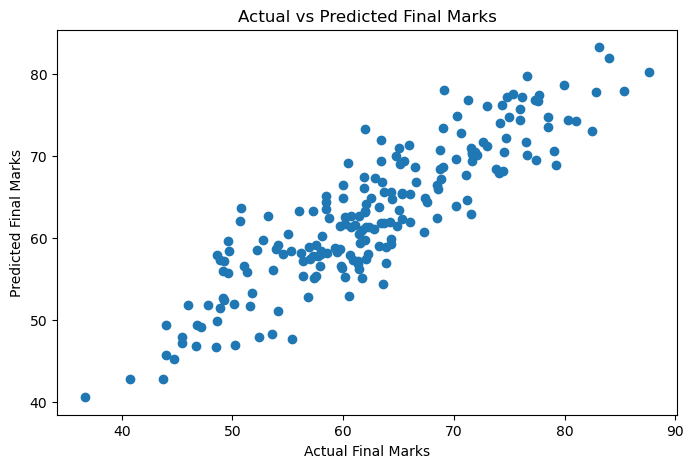

In [13]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_lr)

plt.xlabel("Actual Final Marks")
plt.ylabel("Predicted Final Marks")
plt.title("Actual vs Predicted Final Marks")

plt.show()

In [14]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_lr
})

comparison["Difference"] = comparison["Actual"] - comparison["Predicted"]

comparison.head(10)

,Actual,Predicted,Difference
0,58.0,58.406463,-0.406463
1,76.5,71.708059,4.791941
2,71.6,69.406843,2.193157
3,59.7,61.529114,-1.829114
4,62.2,58.106727,4.093273
5,74.1,67.996729,6.103271
6,48.5,46.649453,1.850547
7,76.0,75.815028,0.184972
8,59.8,56.636959,3.163041
9,58.4,63.568888,-5.168888


In [15]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)


mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("R² Score:", r2_rf)


results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, mae_rf],
    "MSE": [mse, mse_rf],
    "R2 Score": [r2, r2_rf]
})

results

Random Forest Results
---------------------
MAE: 4.312880000000003
MSE: 27.409029550000024
R² Score: 0.7192321975367404


,Model,MAE,MSE,R2 Score
0,Linear Regression,3.614115,20.609639,0.788883
1,Random Forest,4.312880,27.409030,0.719232


In [16]:
##Model Comparison: Two regression models, Linear Regression and Random Forest Regressor, were evaluated using MAE, MSE, and R² Score. Linear Regression achieved an MAE of 3.61, MSE of 20.61, and R² Score of 0.789, while Random Forest achieved an MAE of 4.31, MSE of 27.41, and R² Score of 0.719. Therefore, Linear Regression was selected as the final model because it provided lower prediction errors and a higher R² score.

In [17]:
import joblib
import pandas as pd

loaded_model = joblib.load("student_performance_model.pkl")

def predict_student_performance(study_hours, attendance, previous_score, assignments_score):
    
    student_data = pd.DataFrame({
        "Study_Hours": [study_hours],
        "Attendance": [attendance],
        "Previous_Score": [previous_score],
        "Assignments_Score": [assignments_score]
    })
    
    prediction = loaded_model.predict(student_data)
    
    return prediction[0]


In [18]:
study_hours = float(input("Enter Study Hours: "))
attendance = float(input("Enter Attendance (%): "))
previous_score = float(input("Enter Previous Score: "))
assignments_score = float(input("Enter Assignment Score: "))

prediction = predict_student_performance(
    study_hours,
    attendance,
    previous_score,
    assignments_score
)

print("\nPredicted Final Marks:", round(prediction, 2))

Enter Study Hours:  9
Enter Attendance (%):  79
Enter Previous Score:  80
Enter Assignment Score:  90



Predicted Final Marks: 80.22


In [19]:


study_hours = 10
attendance = 85
previous_score = 75
assignments_score = 80

prediction = predict_student_performance(
    study_hours,
    attendance,
    previous_score,
    assignments_score
)

print("Student Details")
print("----------------")
print("Study Hours:", study_hours)
print("Attendance:", attendance, "%")
print("Previous Score:", previous_score)
print("Assignments Score:", assignments_score)

print("\nPredicted Final Marks:", round(prediction, 2))

Student Details
----------------
Study Hours: 10
Attendance: 85 %
Previous Score: 75
Assignments Score: 80

Predicted Final Marks: 79.54


In [20]:


prediction_result = pd.DataFrame({
    "Study_Hours": [study_hours],
    "Attendance": [attendance],
    "Previous_Score": [previous_score],
    "Assignments_Score": [assignments_score],
    "Predicted_Final_Marks": [round(prediction, 2)]
})

prediction_result

,Study_Hours,Attendance,Previous_Score,Assignments_Score,Predicted_Final_Marks
0,10,85,75,80,79.54


In [21]:


prediction_result.to_csv("student_prediction_result.csv", index=False)

print("Prediction result saved successfully!")

Prediction result saved successfully!


# Conclusion

The Student Performance Predictor project successfully developed a
machine learning system for predicting students' final marks.

The dataset was cleaned by handling missing values and duplicate records.
Exploratory Data Analysis was performed to understand relationships between
study hours, attendance, previous scores, assignment scores, and final marks.

Two regression models were trained and evaluated:

- Linear Regression
- Random Forest Regressor

The models were evaluated using Mean Absolute Error (MAE), Mean Squared
Error (MSE), and R² Score.

Linear Regression was selected as the final model because it performed
better on the test dataset, achieving an MAE of 3.6141, MSE of 20.6096,
and R² Score of 0.7889.

The trained model was saved using Joblib and was successfully used to
predict final marks for new student data.

This project demonstrates the complete machine learning workflow from
data preprocessing and exploratory analysis to model training, evaluation,
model saving, and prediction.

In [22]:
import joblib

joblib.dump(model_lr, "student_performance_model.pkl")

features = [
    "Study_Hours",
    "Attendance",
    "Previous_Score",
    "Assignments_Score"
]

joblib.dump(features, "student_performance_features.pkl")

['student_performance_features.pkl']

In [23]:
loaded_model = joblib.load("student_performance_model.pkl")

student_data = pd.DataFrame({
    "Study_Hours": [8],
    "Attendance": [90],
    "Previous_Score": [80],
    "Assignments_Score": [85]
})

prediction = loaded_model.predict(student_data)

print("Predicted Final Marks:", round(prediction[0], 2))

Predicted Final Marks: 78.87


import ipywidgets as widgets
from IPython.display import display

# Input fields
study_hours_input = widgets.FloatText(
    description="Study Hours:",
    value=5
)

attendance_input = widgets.FloatText(
    description="Attendance:",
    value=75
)

previous_score_input = widgets.FloatText(
    description="Previous Score:",
    value=60
)

assignment_score_input = widgets.FloatText(
    description="Assignment Score:",
    value=60
)

predict_button = widgets.Button(
    description="Predict Final Marks"
)

output = widgets.Output()


def predict_marks(b):
    with output:
        output.clear_output()
        
        student_data = pd.DataFrame({
            "Study_Hours": [study_hours_input.value],
            "Attendance": [attendance_input.value],
            "Previous_Score": [previous_score_input.value],
            "Assignments_Score": [assignment_score_input.value]
        })
        
        prediction = loaded_model.predict(student_data)[0]
        
        print("Predicted Final Marks:", round(prediction, 2))


predict_button.on_click(predict_marks)

display(
    study_hours_input,
    attendance_input,
    previous_score_input,
    assignment_score_input,
    predict_button,
    output
)